In [1]:
pip install scikit-learn scipy seaborn


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [5]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

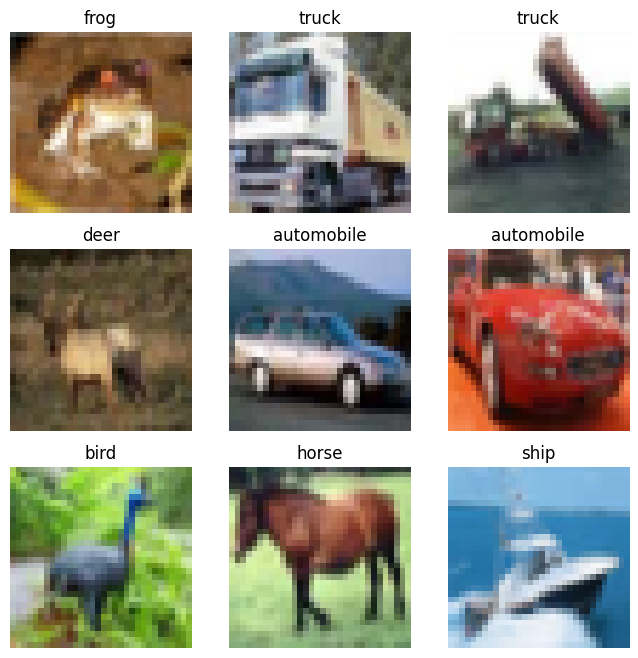

In [7]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [8]:
def create_model(learning_rate=0.001, dropout_rate=0.5):
    model = models.Sequential()

    # Conv Block 1
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D(2,2))

    # Conv Block 2
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    # Conv Block 3
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    # Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
configs = [
    {"lr":0.001, "dropout":0.5},
    {"lr":0.0001, "dropout":0.3},
    {"lr":0.01, "dropout":0.6}
]

histories = []

for cfg in configs:
    print(f"\nTraining with LR={cfg['lr']} Dropout={cfg['dropout']}")

    model = create_model(cfg['lr'], cfg['dropout'])

    history = model.fit(
        x_train, y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=1
    )

    histories.append((cfg, history, model))


Training with LR=0.001 Dropout=0.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3963 - loss: 1.6441 - val_accuracy: 0.5201 - val_loss: 1.3270
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5492 - loss: 1.2668 - val_accuracy: 0.5995 - val_loss: 1.1214
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6120 - loss: 1.1019 - val_accuracy: 0.6386 - val_loss: 1.0269
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6512 - loss: 0.9914 - val_accuracy: 0.6610 - val_loss: 0.9575
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6790 - loss: 0.9191 - val_accuracy: 0.6898 - val_loss: 0.8756
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7014 - loss: 0.8578 - val_accuracy: 0.6979 - val_loss: 0.8568
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7176 - loss: 0.8081 - val_accuracy: 0.6996 - val_loss: 0.8680
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7313 - loss: 0.7657 -

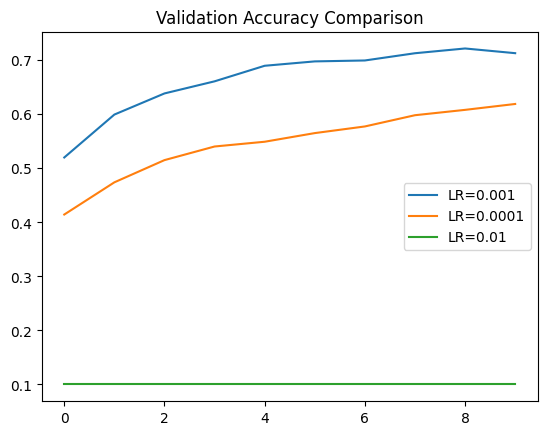

In [10]:
for cfg, history, _ in histories:
    plt.plot(history.history['val_accuracy'], label=f"LR={cfg['lr']}")

plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

In [11]:
best_model = histories[0][2]  # choose best manually based on accuracy

test_loss, test_acc = best_model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7131 - loss: 0.8495
Test Accuracy: 0.713100016117096


In [12]:
for i in range(5):
    pred = best_model.predict(x_test[i:i+1])
    print("Predicted:", class_names[np.argmax(pred)],
          "| Actual:", class_names[y_test[i][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
Predicted: cat | Actual: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted: ship | Actual: ship
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: ship | Actual: ship
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: airplane | Actual: airplane
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: deer | Actual: frog


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


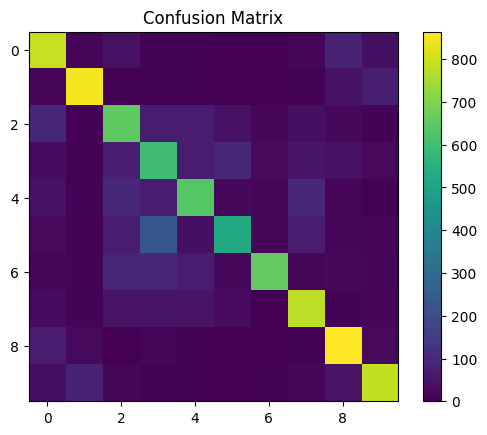

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = tf.math.confusion_matrix(y_test.flatten(), y_pred_classes)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


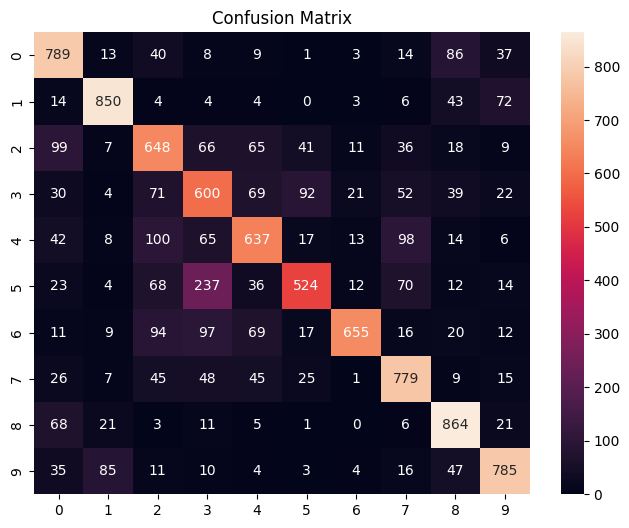

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.69      0.79      0.74      1000
           1       0.84      0.85      0.85      1000
           2       0.60      0.65      0.62      1000
           3       0.52      0.60      0.56      1000
           4       0.68      0.64      0.66      1000
           5       0.73      0.52      0.61      1000
           6       0.91      0.66      0.76      1000
           7       0.71      0.78      0.74      1000
           8       0.75      0.86      0.80      1000
           9       0.79      0.79      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000

